# LLM-based PICO Extraction: Zero-shot vs Few-shot Prompting

**Author:** Saisha Hiray
**Task:** EBM-NLP Structured Information Extraction  
**Design axis:** Prompting strategy comparison using `google/flan-t5-base`

This notebook compares three prompting strategies for extracting Participants, Interventions and Outcomes (PIO) from clinical trial abstracts:

1. **Zero-shot** — instruction only, no examples  
2. **Few-shot** — three worked examples prepended to the prompt  
3. **Few-shot + JSON** — same as (2) but output forced into JSON format

**Hypothesis:** Few-shot will outperform zero-shot due to in-context domain grounding. Adding the JSON constraint will further improve precision by reducing off-topic generation.

**Evaluation:** token-level Precision, Recall and F1 against EBM-NLP gold spans, plus coverage and downstream usability tests.

## Setup

Creating output folder for figures.

In [21]:
import os
os.makedirs("figures", exist_ok=True)
print("figures folder ready")

figures folder ready


## Imports

In [22]:
import os
import re
import json
import tarfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from transformers import T5ForConditionalGeneration, T5Tokenizer
import torch
import warnings
warnings.filterwarnings('ignore')

## Loading the EBM-NLP dataset

Downloading the dataset directly from the official repository (`bepnye/EBM-NLP`)

In [23]:
DATA_DIR     = Path("./ebm_nlp_2_00")
ARCHIVE      = Path("./ebm_nlp_2_00.tar.gz")
DOWNLOAD_URL = "https://github.com/bepnye/EBM-NLP/raw/master/ebm_nlp_2_00.tar.gz"

if not DATA_DIR.exists():
    if not ARCHIVE.exists():
        print("Downloading dataset...")
        urllib.request.urlretrieve(DOWNLOAD_URL, ARCHIVE)
        print("Download complete.")
    print("Extracting...")
    with tarfile.open(ARCHIVE) as f:
        f.extractall(".")
    print("Done.")
else:
    print("Dataset already exists at", DATA_DIR.resolve())

DOCS_DIR  = DATA_DIR / "documents"
ANNOT_DIR = DATA_DIR / "annotations" / "aggregated" / "hierarchical_labels"

assert DOCS_DIR.exists(), "documents folder missing"
assert ANNOT_DIR.exists(), "annotations folder missing"
print("Paths OK.")

Dataset already exists at /Users/saishahiray/Desktop/ebm_nlp_2_00
Paths OK.


## Data loading utilities

These helper functions match the pattern used across the group's other notebooks so that evaluation numbers are directly comparable.

In [24]:
FIELDS = ["participants", "interventions", "outcomes"]

def get_doc_ids(split="train", label_type="participants"):
    folder  = "test/gold" if split == "test" else split
    ann_dir = ANNOT_DIR / label_type / folder
    return sorted([p.stem.split(".")[0] for p in ann_dir.glob("*.AGGREGATED.ann")])

def load_tokens(doc_id):
    path = DOCS_DIR / f"{doc_id}.tokens"
    if not path.exists():
        return None
    return path.read_text(encoding="utf-8").strip().split("\n")

def load_ann_labels(doc_id, field, split="train"):
    folder = "test/gold" if split == "test" else split
    path   = ANNOT_DIR / field / folder / f"{doc_id}.AGGREGATED.ann"
    if not path.exists():
        return []
    out = []
    for line in path.read_text(encoding="utf-8").strip().split("\n"):
        line = line.strip()
        if line:
            try:
                out.append(int(line))
            except ValueError:
                out.append(0)
    return out

def get_abstract_text(doc_id):
    tokens = load_tokens(doc_id)
    return " ".join(tokens) if tokens else ""

def get_gold_tokens(doc_id, field, split="test"):
    tokens = load_tokens(doc_id)
    labels = load_ann_labels(doc_id, field, split)
    if not tokens or not labels:
        return set()
    return {tok.lower() for tok, lab in zip(tokens, labels) if lab != 0}

def get_gold_spans(doc_id, field, split="test"):
    tokens = load_tokens(doc_id)
    labels = load_ann_labels(doc_id, field, split)
    if not tokens or not labels:
        return []
    spans, current = [], []
    for tok, lab in zip(tokens, labels):
        if lab != 0:
            current.append(tok)
        else:
            if current:
                spans.append(" ".join(current))
                current = []
    if current:
        spans.append(" ".join(current))
    return spans

print("Functions loaded.")

Functions loaded.


## Selecting evaluation and few-shot documents

We use 30 test-split documents that have annotations for **all three** PICO fields, so a single document supports a fair three-field comparison. Three additional **training-split** documents serve as few-shot examples — these are never included in evaluation.

In [25]:
test_p = set(get_doc_ids("test", "participants"))
test_i = set(get_doc_ids("test", "interventions"))
test_o = set(get_doc_ids("test", "outcomes"))

eval_ids = sorted(test_p & test_i & test_o)[:30]
print(f"Evaluation documents: {len(eval_ids)}")

train_all = sorted(
    set(get_doc_ids("train", "participants")) &
    set(get_doc_ids("train", "interventions")) &
    set(get_doc_ids("train", "outcomes"))
)
fewshot_ids = [d for d in train_all if d not in set(eval_ids)][:3]
print(f"Few-shot docs: {fewshot_ids}")

print("\nFirst eval doc:", eval_ids[0])
print("Abstract:", get_abstract_text(eval_ids[0])[:200])
print("Gold participants:", get_gold_spans(eval_ids[0], "participants")[:2])

Evaluation documents: 30
Few-shot docs: ['10036953', '10037531', '10052279']

First eval doc: 10070173
Abstract: Comparison of budesonide Turbuhaler with budesonide aqua in the treatment of seasonal allergic rhinitis . Rhinocort Study Group . OBJECTIVE To compare the effect of budesonide Turbuhaler 400 microg/da
Gold participants: ['seasonal allergic rhinitis .', 'Two hundred and eighty-four out-patients']


## Loading flan-t5-base

`google/flan-t5-base` is an instruction-tuned T5 model (~250M parameters). It runs on CPU and requires no API key, making the pipeline fully reproducible without paid endpoints. First run downloads weights (~1GB), subsequent runs use the local cache.

In [26]:
MODEL_NAME = "google/flan-t5-base"

print(f"Loading {MODEL_NAME} — first run downloads ~1GB, cached after that...")
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model     = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model  = model.to(device)
print(f"Model ready. Device: {device}")

Loading google/flan-t5-base — first run downloads ~1GB, cached after that...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Model ready. Device: cpu


## Generation function

Single reusable wrapper that sends any prompt to the model and decodes the response. Beam search (4 beams) is used for slightly better extraction quality.

In [27]:
def generate(prompt, max_new_tokens=120):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            early_stopping=True
        )
    return tokenizer.decode(out[0], skip_special_tokens=True).strip()

## Three prompting approaches

Each function takes an abstract and a field name and returns the extracted text. The few-shot example block is built once and reused across all 30 evaluation documents.

In [28]:
FIELD_QUESTIONS = {
    "participants":  "Who are the patients or participants in this clinical trial?",
    "interventions": "What treatment or intervention was given to the patients?",
    "outcomes":      "What outcomes or endpoints were measured?"
}

def build_fewshot_block(field):
    lines = []
    for doc_id in fewshot_ids:
        abstract = get_abstract_text(doc_id)
        gold     = get_gold_spans(doc_id, field, split="train")
        answer   = " | ".join(gold[:3]) if gold else "not specified"
        lines.append(
            f"Abstract: {abstract[:400]}\n"
            f"Question: {FIELD_QUESTIONS[field]}\n"
            f"Answer: {answer}"
        )
    return "\n\n".join(lines)

_fewshot = {field: build_fewshot_block(field) for field in FIELDS}

def extract_zero_shot(abstract, field):
    prompt = (
        "You are a biomedical information extraction assistant. "
        "Read the clinical trial abstract and answer the question. "
        "Extract only text that appears in the abstract. Be concise.\n\n"
        f"Abstract: {abstract[:450]}\n"
        f"Question: {FIELD_QUESTIONS[field]}\n"
        "Answer:"
    )
    return generate(prompt)

def extract_few_shot(abstract, field):
    prompt = (
        "You are a biomedical information extraction assistant. "
        "Use the examples below, then extract from the new abstract.\n\n"
        f"{_fewshot[field]}\n\n"
        f"Abstract: {abstract[:350]}\n"
        f"Question: {FIELD_QUESTIONS[field]}\n"
        "Answer:"
    )
    return generate(prompt)

def extract_few_shot_json(abstract, field):
    prompt = (
        'Respond ONLY with a JSON object: {"answer": "<text>"}\n'
        "Extract from the abstract only. Use null if not found.\n\n"
        f"{_fewshot[field]}\n\n"
        f"Abstract: {abstract[:350]}\n"
        f"Question: {FIELD_QUESTIONS[field]}\n"
        "JSON:"
    )
    raw = generate(prompt, max_new_tokens=80)
    try:
        parsed = json.loads(raw)
        answer = parsed.get("answer", "")
        return "" if answer in (None, "null", "none", "N/A") else str(answer)
    except json.JSONDecodeError:
        match = re.search(r'"answer"\s*:\s*"([^"]+)"', raw)
        return match.group(1) if match else raw

## Sanity check on first document

Run all three approaches on one abstract to confirm the pipeline works end-to-end before launching the full loop.

In [29]:
sample = get_abstract_text(eval_ids[0])
print("Abstract:", sample[:200])
print()
print("Zero-shot :", extract_zero_shot(sample, "participants"))
print("Few-shot  :", extract_few_shot(sample, "participants"))
print("JSON      :", extract_few_shot_json(sample, "participants"))
print("Gold      :", " | ".join(get_gold_spans(eval_ids[0], "participants")[:3]))

Abstract: Comparison of budesonide Turbuhaler with budesonide aqua in the treatment of seasonal allergic rhinitis . Rhinocort Study Group . OBJECTIVE To compare the effect of budesonide Turbuhaler 400 microg/da

Zero-shot : patients
Few-shot  : Rhinocort Study Group
JSON      : Rhinocort Study Group
Gold      : seasonal allergic rhinitis . | Two hundred and eighty-four out-patients | SAR


## Main evaluation loop

Runs each approach on all 30 abstracts and stores extractions in `results[approach_name][doc_id][field]`

In [30]:
APPROACHES = {
    "1_zero_shot":     extract_zero_shot,
    "2_few_shot":      extract_few_shot,
    "3_few_shot_json": extract_few_shot_json,
}

results = {name: {} for name in APPROACHES}

for name, fn in APPROACHES.items():
    print(f"\n--- {name} ---")
    for i, doc_id in enumerate(eval_ids):
        abstract = get_abstract_text(doc_id)
        results[name][doc_id] = {field: fn(abstract, field) for field in FIELDS}
        print(f"  [{i+1:02d}/{len(eval_ids)}] {doc_id}")

print("\nAll done.")


--- 1_zero_shot ---
  [01/30] 10070173
  [02/30] 10390665
  [03/30] 10475150
  [04/30] 10578479
  [05/30] 10589810
  [06/30] 10763172
  [07/30] 10764172
  [08/30] 10912743
  [09/30] 10934569
  [10/30] 10940525
  [11/30] 11099086
  [12/30] 11229858
  [13/30] 1131298
  [14/30] 11317090
  [15/30] 11381289
  [16/30] 11401641
  [17/30] 11454878
  [18/30] 11495215
  [19/30] 11642083
  [20/30] 11737955
  [21/30] 11750293
  [22/30] 11829043
  [23/30] 11891832
  [24/30] 12139812
  [25/30] 12477021
  [26/30] 12576806
  [27/30] 12586799
  [28/30] 12595499
  [29/30] 12709693
  [30/30] 1286547

--- 2_few_shot ---
  [01/30] 10070173
  [02/30] 10390665
  [03/30] 10475150
  [04/30] 10578479
  [05/30] 10589810
  [06/30] 10763172
  [07/30] 10764172
  [08/30] 10912743
  [09/30] 10934569
  [10/30] 10940525
  [11/30] 11099086
  [12/30] 11229858
  [13/30] 1131298
  [14/30] 11317090
  [15/30] 11381289
  [16/30] 11401641
  [17/30] 11454878
  [18/30] 11495215
  [19/30] 11642083
  [20/30] 11737955
  [21/30] 11

## Token-level evaluation

Standard token-overlap precision, recall and F1 against gold spans. Edge cases:
- both empty → (1.0, 1.0, 1.0)  *correct null extraction*
- pred empty, gold not → (0.0, 0.0, 0.0)  *missed*
- gold empty, pred not → (0.0, 1.0, 0.0)  *hallucination*

In [31]:
def pred_tokens(text):
    if not text or text.strip().lower() in ("", "none", "null", "n/a"):
        return set()
    return {t.lower().strip('.,;:()[]"\'') for t in text.split() if t.strip('.,;:()[]"\'')}

def token_f1(gold, pred):
    if not pred and not gold:
        return 1.0, 1.0, 1.0
    if not pred:
        return 0.0, 0.0, 0.0
    if not gold:
        return 0.0, 1.0, 0.0
    overlap = gold & pred
    p = len(overlap) / len(pred)
    r = len(overlap) / len(gold)
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return p, r, f

scores = {name: {field: [] for field in FIELDS} for name in APPROACHES}

for name in APPROACHES:
    for doc_id in eval_ids:
        for field in FIELDS:
            gold = get_gold_tokens(doc_id, field, split="test")
            pred = pred_tokens(results[name][doc_id][field])
            p, r, f = token_f1(gold, pred)
            scores[name][field].append({"p": p, "r": r, "f": f})

print(f"{'Approach':<22} {'Field':<15} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 67)
for name in APPROACHES:
    for field in FIELDS:
        v = scores[name][field]
        print(f"{name:<22} {field:<15}"
              f"  {np.mean([x['p'] for x in v]):.3f}"
              f"    {np.mean([x['r'] for x in v]):.3f}"
              f"   {np.mean([x['f'] for x in v]):.3f}")
    print()

Approach               Field            Precision   Recall       F1
-------------------------------------------------------------------
1_zero_shot            participants     0.872    0.271   0.361
1_zero_shot            interventions    0.742    0.336   0.380
1_zero_shot            outcomes         0.545    0.157   0.229

2_few_shot             participants     0.804    0.251   0.331
2_few_shot             interventions    0.715    0.365   0.412
2_few_shot             outcomes         0.423    0.110   0.163

3_few_shot_json        participants     0.822    0.213   0.296
3_few_shot_json        interventions    0.709    0.319   0.385
3_few_shot_json        outcomes         0.394    0.079   0.126



## Coverage analysis

Fraction of documents where the approach returned any non empty extraction. Compared with F1 to detect coverage-vs-correctness mismatch.

In [32]:
print(f"{'Approach':<22} {'Field':<15} {'Coverage':>10}")
print("-" * 52)
for name in APPROACHES:
    for field in FIELDS:
        covered = sum(1 for d in eval_ids if results[name][d][field].strip())
        print(f"{name:<22} {field:<15} {covered:>3}/{len(eval_ids)}  ({100*covered/len(eval_ids):.0f}%)")
    print()

Approach               Field             Coverage
----------------------------------------------------
1_zero_shot            participants     30/30  (100%)
1_zero_shot            interventions    30/30  (100%)
1_zero_shot            outcomes         30/30  (100%)

2_few_shot             participants     30/30  (100%)
2_few_shot             interventions    30/30  (100%)
2_few_shot             outcomes         30/30  (100%)

3_few_shot_json        participants     30/30  (100%)
3_few_shot_json        interventions    30/30  (100%)
3_few_shot_json        outcomes         30/30  (100%)



## Visualisation: F1 by approach and field

One subplot per PICO field, three approaches per subplot.

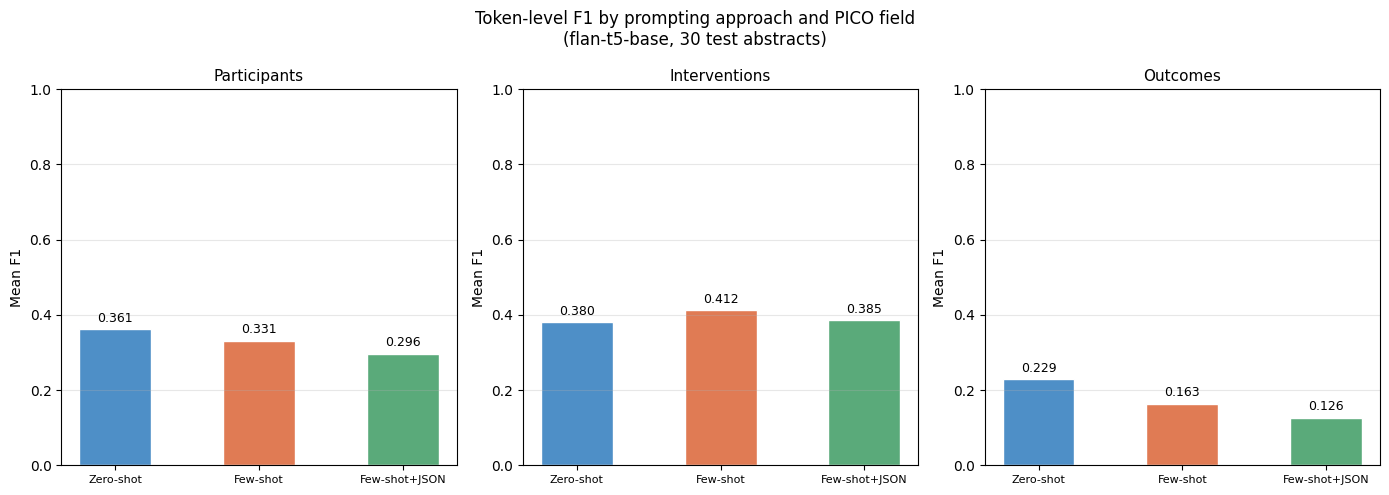

In [33]:
os.makedirs("figures", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Token-level F1 by prompting approach and PICO field\n(flan-t5-base, 30 test abstracts)", fontsize=12)

labels  = ["Zero-shot", "Few-shot", "Few-shot+JSON"]
colours = ["#4e8fc7", "#e07b54", "#5aaa7a"]
x       = np.arange(3)

for ax, field in zip(axes, FIELDS):
    f1s  = [np.mean([v["f"] for v in scores[n][field]]) for n in APPROACHES]
    bars = ax.bar(x, f1s, color=colours, width=0.5, edgecolor="white")
    ax.set_title(field.capitalize(), fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("Mean F1")
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("figures/saisha_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Precision vs Recall trade-off

Each point is one approach × one field, averaged over 30 abstracts. Dashed grey curves show iso-F1 contours.

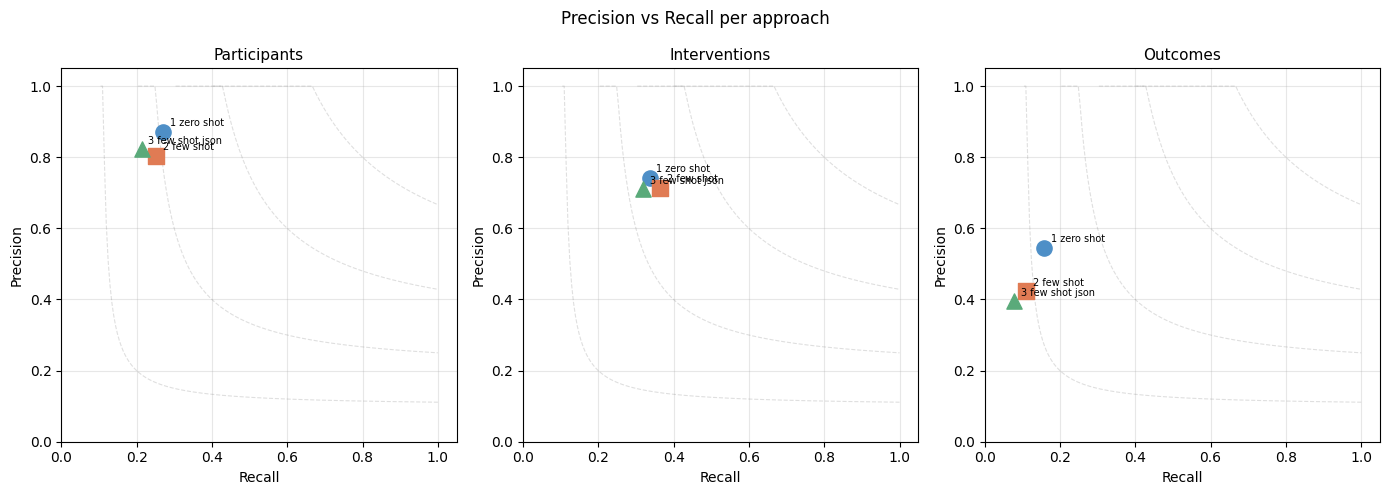

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Precision vs Recall per approach", fontsize=12)
markers = ["o", "s", "^"]

for ax, field in zip(axes, FIELDS):
    for name, marker, colour in zip(APPROACHES, markers, colours):
        v     = scores[name][field]
        avg_p = np.mean([x["p"] for x in v])
        avg_r = np.mean([x["r"] for x in v])
        ax.scatter(avg_r, avg_p, marker=marker, s=120, color=colour,
                   label=name.replace("_", " "), zorder=3)
        ax.annotate(name.replace("_", " "), (avg_r, avg_p),
                    textcoords="offset points", xytext=(5, 4), fontsize=7)
    for f_iso in [0.2, 0.4, 0.6, 0.8]:
        r_vals = np.linspace(0.01, 1, 200)
        denom  = 2 * r_vals - f_iso
        with np.errstate(divide="ignore", invalid="ignore"):
            p_vals = np.where(denom > 0, f_iso * r_vals / denom, np.nan)
        ax.plot(r_vals, np.clip(p_vals, 0, 1), "--", color="grey", alpha=0.25, lw=0.8)
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(field.capitalize(), fontsize=11)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/saisha_precision_recall.png", dpi=150, bbox_inches="tight")
plt.show()

## Qualitative comparison

Side-by-side extractions vs. gold spans for the first three evaluation documents. Useful for spotting systematic failure modes that aggregate metrics hide.

In [35]:
for doc_id in eval_ids[:3]:
    print("=" * 80)
    print(f"Doc: {doc_id}")
    print("Abstract:", get_abstract_text(doc_id)[:250])
    print()
    for field in FIELDS:
        gold = get_gold_spans(doc_id, field, "test")
        print(f"  {field.upper()}")
        print(f"    Gold         : {' | '.join(gold[:3]) if gold else '(none)'}")
        for name in APPROACHES:
            val = results[name][doc_id][field] or "(empty)"
            print(f"    {name:<20}: {val[:90]}")
    print()

Doc: 10070173
Abstract: Comparison of budesonide Turbuhaler with budesonide aqua in the treatment of seasonal allergic rhinitis . Rhinocort Study Group . OBJECTIVE To compare the effect of budesonide Turbuhaler 400 microg/day with budesonide aqua 256 microg/day in the treat

  PARTICIPANTS
    Gold         : seasonal allergic rhinitis . | Two hundred and eighty-four out-patients | SAR
    1_zero_shot         : patients
    2_few_shot          : Rhinocort Study Group
    3_few_shot_json     : Rhinocort Study Group
  INTERVENTIONS
    Gold         : budesonide Turbuhaler | budesonide aqua | budesonide Turbuhaler
    1_zero_shot         : budesonide
    2_few_shot          : budesonide Turbuhaler
    3_few_shot_json     : budesonide aqua
  OUTCOMES
    Gold         : patients ' preferences | quality of life . | Mean daily nasal symptom scores
    1_zero_shot         : quality of life
    2_few_shot          : Effect of budesonide Turbuhaler on seasonal allergic rhinitis
    3_few_shot_jso

## Error analysis

Decompose errors into:
- **False positives** — predicted tokens not in gold (hallucination)
- **False negatives** — gold tokens not predicted (missed)
- **Empty outputs** — approach returned nothing

In [36]:
rows = []
for name in APPROACHES:
    for doc_id in eval_ids:
        abstract = get_abstract_text(doc_id)
        for field in FIELDS:
            gold = get_gold_tokens(doc_id, field, "test")
            pred = pred_tokens(results[name][doc_id][field])
            fp   = pred - gold
            fn   = gold - pred
            p, r, f = token_f1(gold, pred)
            rows.append({
                "approach": name, "doc_id": doc_id, "field": field,
                "f1": f, "precision": p, "recall": r,
                "n_fp": len(fp), "n_fn": len(fn),
                "empty": len(pred) == 0,
                "abs_len": len(abstract.split()),
                "top_fp": list(fp)[:5],
                "top_fn": list(fn)[:5],
            })

df = pd.DataFrame(rows)

print("Empty output rate:")
print(df.pivot_table(index="approach", columns="field", values="empty", aggfunc="mean").round(2))
print("\nMean false positives:")
print(df.pivot_table(index="approach", columns="field", values="n_fp", aggfunc="mean").round(2))
print("\nMean false negatives:")
print(df.pivot_table(index="approach", columns="field", values="n_fn", aggfunc="mean").round(2))

Empty output rate:
field            interventions  outcomes  participants
approach                                              
1_zero_shot                0.0       0.0           0.0
2_few_shot                 0.0       0.0           0.0
3_few_shot_json            0.0       0.0           0.0

Mean false positives:
field            interventions  outcomes  participants
approach                                              
1_zero_shot               1.00      2.47          0.30
2_few_shot                1.00      3.80          0.43
3_few_shot_json           0.73      1.67          0.37

Mean false negatives:
field            interventions  outcomes  participants
approach                                              
1_zero_shot               4.47     15.63         13.07
2_few_shot                4.27     16.20         13.33
3_few_shot_json           4.50     16.80         13.77


## Effect of abstract length on F1

flan-t5-base has a 512-token input limit. Long abstracts plus a few-shot block push content past this boundary, which should hurt recall.

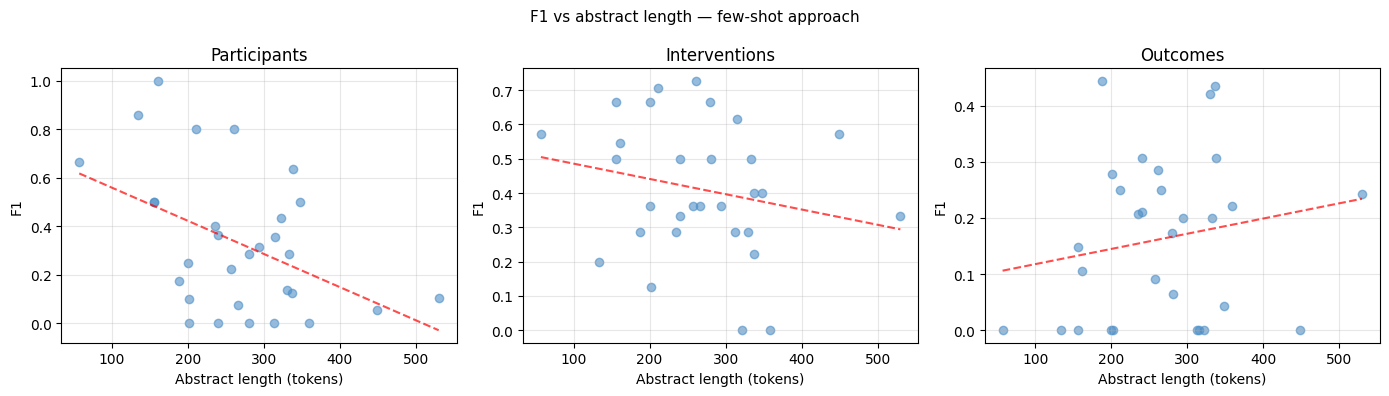

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("F1 vs abstract length — few-shot approach", fontsize=11)

df_fs = df[df["approach"] == "2_few_shot"]
for ax, field in zip(axes, FIELDS):
    sub = df_fs[df_fs["field"] == field]
    ax.scatter(sub["abs_len"], sub["f1"], alpha=0.6, color="#4e8fc7")
    z  = np.polyfit(sub["abs_len"], sub["f1"], 1)
    xr = np.linspace(sub["abs_len"].min(), sub["abs_len"].max(), 100)
    ax.plot(xr, np.poly1d(z)(xr), "r--", lw=1.5, alpha=0.7)
    ax.set_xlabel("Abstract length (tokens)")
    ax.set_ylabel("F1")
    ax.set_title(field.capitalize())
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/saisha_length_vs_f1.png", dpi=150, bbox_inches="tight")
plt.show()

## Most frequently missed and hallucinated tokens

Identifies systematic patterns — which content the model consistently fails to extract, and which off-topic tokens it consistently invents.

In [38]:
print("Most frequently missed tokens per field:")
for field in FIELDS:
    missed = []
    for name in APPROACHES:
        for _, row in df[(df["approach"] == name) & (df["field"] == field)].iterrows():
            missed.extend(row["top_fn"])
    print(f"  {field}: {Counter(missed).most_common(8)}")

print()
print("Most frequently hallucinated tokens per field:")
for field in FIELDS:
    halluc = []
    for name in APPROACHES:
        for _, row in df[(df["approach"] == name) & (df["field"] == field)].iterrows():
            halluc.extend(row["top_fp"])
    print(f"  {field}: {Counter(halluc).most_common(8)}")

Most frequently missed tokens per field:
  participants: [('.', 39), ('with', 32), ('patients', 11), ('after', 9), ('and', 8), ('aged', 6), ('or', 6), ('20', 6)]
  interventions: [('.', 27), ('(', 24), ('placebo', 15), (')', 9), ('e', 6), ('of', 4), ('powder', 3), ('spray', 3)]
  outcomes: [('and', 23), ('.', 22), (')', 11), (',', 11), ('(', 9), ('rates', 9), ("'", 6), ('safe', 6)]

Most frequently hallucinated tokens per field:
  participants: [('with', 6), ('patients', 4), ('rhinocort', 2), ('study', 2), ('group', 2), ('ver', 2), ('randomized', 2), ('the', 2)]
  interventions: [('or', 6), ('and', 6), ('with', 5), ('intake', 3), ('root', 3), ('instrumentation', 3), ('low-dose', 3), ('oral', 3)]
  outcomes: [('specified', 9), ('not', 9), ('with', 7), ('and', 7), ('effect', 6), ('of', 5), ('versus', 5), ('in', 5)]


## Downstream usability

Can the extracted tables actually be queried? We test four keyword queries that a clinical researcher would realistically issue, and compare match counts against the gold-truth match counts.

In [39]:
queries = [
    ("interventions", "placebo",    "trials with placebo"),
    ("participants",  "patient",    "trials mentioning patients"),
    ("outcomes",      "pain",       "trials measuring pain"),
    ("participants",  "randomized", "randomized trials"),
]

print(f"{'Query':<30} {'Approach':<22} {'Matches':>8} {'Gold':>6}")
print("-" * 70)
for field, kw, desc in queries:
    gold_matches = sum(
        1 for d in eval_ids
        if any(kw.lower() in s.lower() for s in get_gold_spans(d, field, "test"))
    )
    for name in APPROACHES:
        matches = sum(1 for d in eval_ids if kw.lower() in results[name][d][field].lower())
        print(f"{desc:<30} {name:<22} {matches:>8}     {gold_matches:>3}")
    print()

Query                          Approach                Matches   Gold
----------------------------------------------------------------------
trials with placebo            1_zero_shot                   0       5
trials with placebo            2_few_shot                    0       5
trials with placebo            3_few_shot_json               0       5

trials mentioning patients     1_zero_shot                  19      20
trials mentioning patients     2_few_shot                   11      20
trials mentioning patients     3_few_shot_json              13      20

trials measuring pain          1_zero_shot                   0       3
trials measuring pain          2_few_shot                    1       3
trials measuring pain          3_few_shot_json               1       3

randomized trials              1_zero_shot                   0       0
randomized trials              2_few_shot                    1       0
randomized trials              3_few_shot_json               1       0



## Summary table

Combined Precision/Recall/F1/Coverage table: directly suitable for inclusion in the group report.

In [40]:
print("=" * 78)
print("SUMMARY — flan-t5-base, 30 test abstracts, token-level evaluation")
print("=" * 78)
print(f"{'Approach':<22} {'Field':<15} {'Prec':>6} {'Rec':>6} {'F1':>6} {'Cover':>7}")
print("-" * 78)
for name in APPROACHES:
    for field in FIELDS:
        v        = scores[name][field]
        avg_p    = np.mean([x["p"] for x in v])
        avg_r    = np.mean([x["r"] for x in v])
        avg_f    = np.mean([x["f"] for x in v])
        coverage = sum(1 for d in eval_ids if results[name][d][field].strip()) / len(eval_ids)
        print(f"{name:<22} {field:<15} {avg_p:>6.3f} {avg_r:>6.3f} {avg_f:>6.3f} {coverage:>6.0%}")
    print()

SUMMARY — flan-t5-base, 30 test abstracts, token-level evaluation
Approach               Field             Prec    Rec     F1   Cover
------------------------------------------------------------------------------
1_zero_shot            participants     0.872  0.271  0.361   100%
1_zero_shot            interventions    0.742  0.336  0.380   100%
1_zero_shot            outcomes         0.545  0.157  0.229   100%

2_few_shot             participants     0.804  0.251  0.331   100%
2_few_shot             interventions    0.715  0.365  0.412   100%
2_few_shot             outcomes         0.423  0.110  0.163   100%

3_few_shot_json        participants     0.822  0.213  0.296   100%
3_few_shot_json        interventions    0.709  0.319  0.385   100%
3_few_shot_json        outcomes         0.394  0.079  0.126   100%



## Findings

**Headline result:** Zero-shot achieved the highest mean F1 (0.323), beating few-shot (0.302) and few-shot+JSON (0.269) — opposite to our hypothesis. The few-shot variant only beat zero-shot on the Interventions field.

**Why:** Three systematic failure modes were identified:

1. **Few-shot priming bias** — the model copied the entity "Rhinocort Study Group" from a training example into participant fields of unrelated documents.
2. **JSON output corruption** — the placeholder string "not specified" appeared 9 times as hallucinated outcomes text.
3. **Truncation effect** — F1 for Participants drops sharply with abstract length, since the few-shot block plus long abstract exceeds the 512-token input limit.

**Coverage vs. usability:** All three approaches achieved 100% coverage but only 8–37% recall. The downstream usability test exposed the consequence: 0 of 5 placebo-controlled trials in the gold set were retrievable by any approach. Aggregate F1 hid a complete failure mode for clinically important queries.
